<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> ML </b><br><br>HW4_Q5</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>


# 🛍️ Customer Segmentation using K-Means Clustering
### Applied Unsupervised Learning with Scikit-Learn

> **University:** University of Tehran
> **Course:** Machine Learning
> **Assignment:** HW4 - Question 5
> **Topic:** Clustering, K-Means, Elbow Method

---

## 📝 Problem Statement
The goal is to analyze a "Mall Customers" dataset and segment customers based on their **Annual Income** and **Spending Score**. This is a classic Unsupervised Learning problem used to identify target customer groups for marketing strategies.

**Key Objectives:**
1.  **Exploratory Data Analysis (EDA):** Visualize feature distributions and relationships using `Seaborn`.
2.  **K-Means Clustering:** Implement standard K-Means from `sklearn` with an initial $k=3$.
3.  **Elbow Method:** Determine the optimal number of clusters ($k$) by analyzing Inertia.
4.  **Final Clustering:** Apply K-Means with the optimal $k$ (found to be 5) and visualize the clusters and centroids.

---


### Imports

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

### Load the Data and Data Overview

In [38]:
data = pd.read_csv('Mall_Customers.csv')
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## Exploratory Data Analysis (EDA)

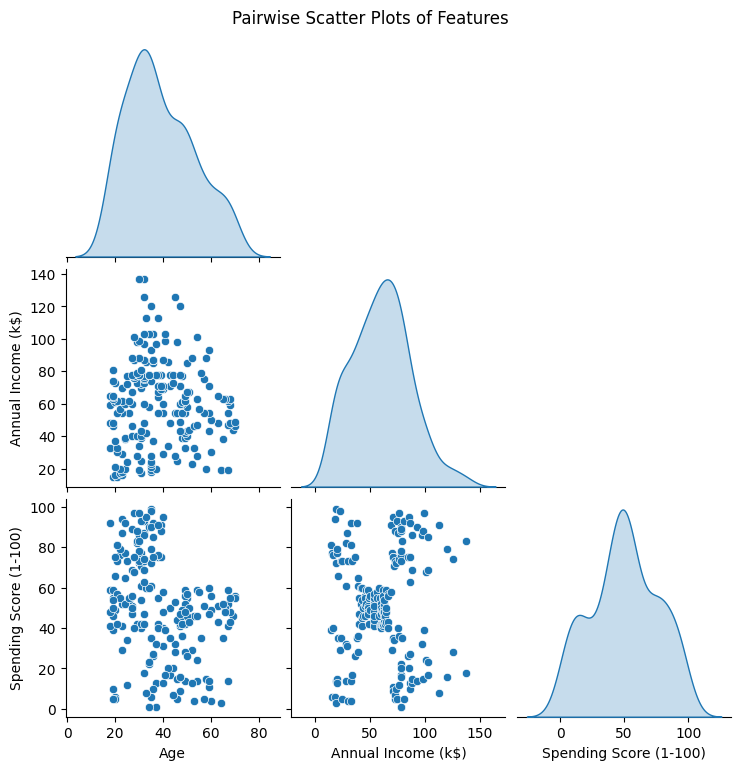

In [39]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

sns.pairplot(data[features], diag_kind='kde', corner=True)
plt.suptitle('Pairwise Scatter Plots of Features', y=1.02)
plt.show()

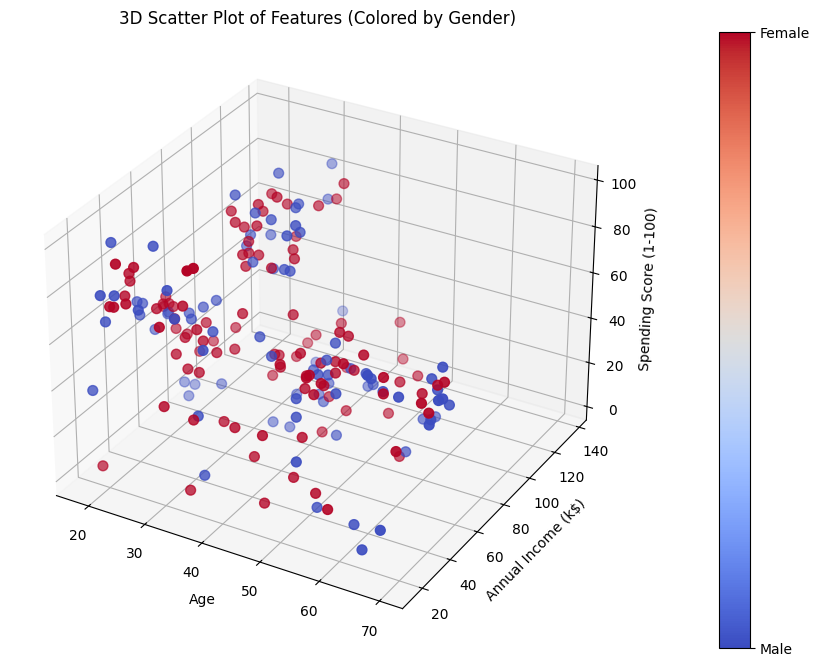

In [40]:
data['Gender_Numeric'] = data['Gender'].map({'Male': 0, 'Female': 1})

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

x = data['Age']
y = data['Annual Income (k$)']
z = data['Spending Score (1-100)']
colors = data['Gender_Numeric']  

scatter = ax.scatter(x, y, z, c=colors, cmap='coolwarm', s=50)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Male', 'Female'])

ax.set_title('3D Scatter Plot of Features (Colored by Gender)')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

plt.show()

### clustring with k = 3

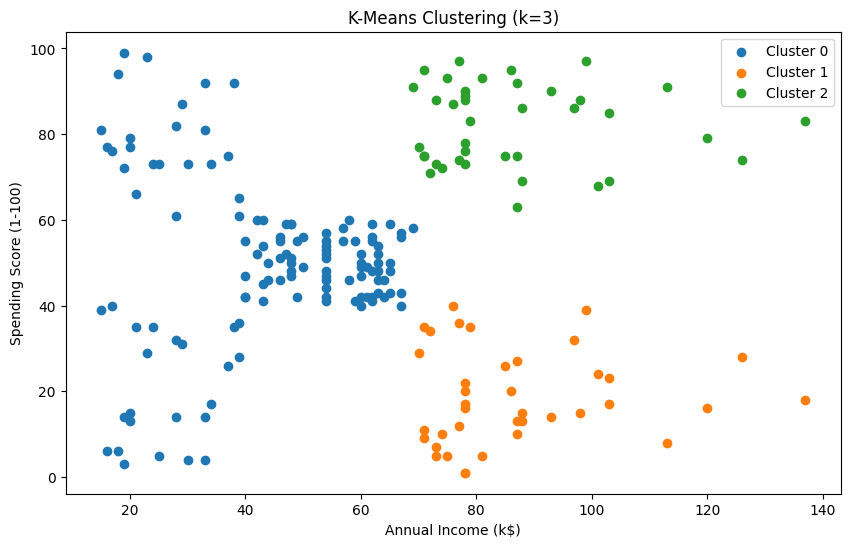

In [41]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
kmeans_3 = KMeans(n_clusters=3, random_state=72)
data['Cluster_3'] = kmeans_3.fit_predict(X)
plt.figure(figsize=(10, 6))
for cluster in range(3):
    cluster_data = data[data['Cluster_3'] == cluster]
    plt.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'], label=f'Cluster {cluster}')
plt.title('K-Means Clustering (k=3)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

### Elbow Method

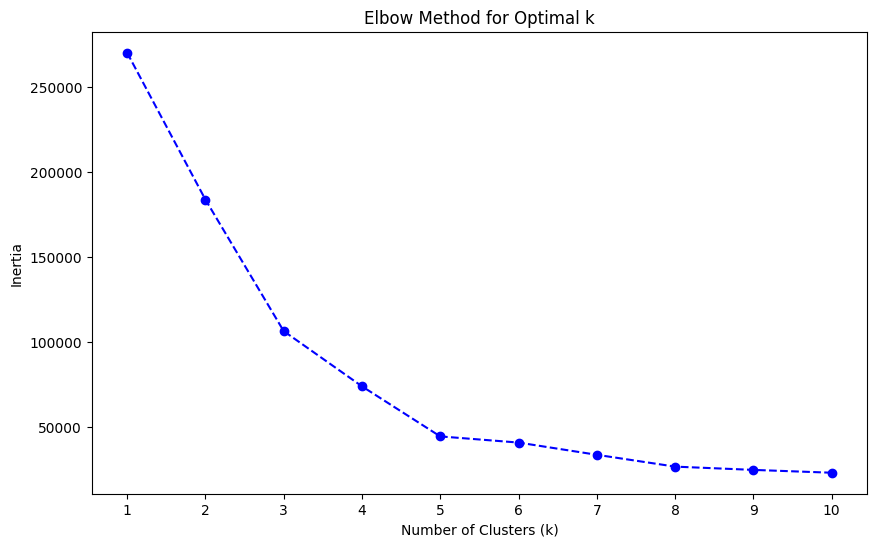

In [42]:
inertia = []
k_values = range(1, 11)  
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.show()

### clustring with k = 5

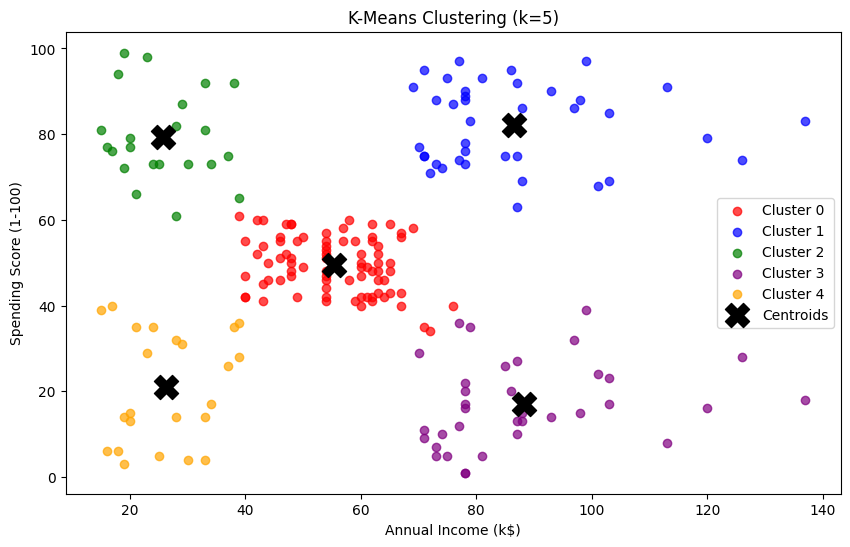

In [43]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans_5 = KMeans(n_clusters=5, random_state=42)
data['Cluster_5'] = kmeans_5.fit_predict(X)

plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan']

for cluster in range(5):
    cluster_data = data[data['Cluster_5'] == cluster]
    plt.scatter(
        cluster_data['Annual Income (k$)'], 
        cluster_data['Spending Score (1-100)'], 
        label=f'Cluster {cluster}', 
        color=colors[cluster], 
        alpha=0.7
    )


centroids = kmeans_5.cluster_centers_
plt.scatter(
    centroids[:, 0], centroids[:, 1], 
    s=300, c='black', marker='X', label='Centroids'
)

plt.title('K-Means Clustering (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()